# $T_c$-$n_c$ all Models vs assymetric Clausius 

In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

repo_root = Path("/Users/dajuarez4/Documents/QuarkMatt/nuclear_matter_workflows")
results_dir = repo_root / "results"
output_dir = results_dir / "tc_nc_comparison_combined_vs_clausius_fixed_y"
output_dir.mkdir(parents=True, exist_ok=True)

pd.set_option("display.precision", 6)

TARGET_K0S = [250.0, 280.0, 315.0]
COLOR_MAP = {
    "vdw": "black",
    "cs": "tab:blue",
    "tvm": "tab:red",
    "rks": "tab:orange",
    "pr": "tab:green",
    250.0: "magenta",
    280.0: "royalblue",
    315.0: "darkgreen",
}

output_dir

PosixPath('/Users/dajuarez4/Documents/QuarkMatt/nuclear_matter_workflows/results/tc_nc_comparison_combined_vs_clausius_fixed_y')

In [6]:
base_df = pd.read_csv(results_dir / 'extended_quantum_base.csv')[['model', 'label', 'K0', 'Tc', 'nc', 'Pc']].copy()
base_df['source'] = 'combined_base_model'
base_df['comparison_label'] = base_df['label']

scan_config = {
    'clausius': {
        'csv_name': 'extended_quantum_clausius.csv',
        'parameter_name': 'c',
        'display_name': 'Clausius scan',
        'source': 'combined_clausius_scan_nearest',
    },
    'dieterici': {
        'csv_name': 'extended_quantum_dieterici.csv',
        'parameter_name': 'alpha',
        'display_name': 'Dieterici scan',
        'source': 'combined_dieterici_scan_nearest',
    },
}

scan_frames = {}
scan_reference_rows = []
for scan_model, cfg in scan_config.items():
    scan_full_df = pd.read_csv(results_dir / cfg['csv_name'])[['parameter_value', 'K0', 'Tc', 'nc', 'Pc']].copy()
    scan_full_df['scan_model'] = scan_model
    scan_full_df['display_name'] = cfg['display_name']
    scan_frames[scan_model] = scan_full_df

    for target_k0 in TARGET_K0S:
        nearest = (
            scan_full_df.assign(delta_k0=(scan_full_df['K0'] - target_k0).abs())
            .sort_values(['delta_k0', 'K0'])
            .iloc[0]
        )
        scan_reference_rows.append(
            {
                'source': cfg['source'],
                'scan_model': scan_model,
                'comparison_label': f"{cfg['display_name']} near K0={int(target_k0)}",
                'target_k0': target_k0,
                'parameter_name': cfg['parameter_name'],
                'parameter_value': nearest['parameter_value'],
                'K0': nearest['K0'],
                'Tc': nearest['Tc'],
                'nc': nearest['nc'],
                'Pc': nearest['Pc'],
                'delta_k0': nearest['delta_k0'],
            }
        )
scan_reference_df = pd.DataFrame(scan_reference_rows)
scan_reference_df.to_csv(output_dir / 'tc_nc_scan_reference_values.csv', index=False)

fixed_y_df = pd.read_csv(
    results_dir / 'asymmetric_clausius_finite_temperature_fixed_y' / 'asymmetric_clausius_fixed_y_tc_nc.csv'
)[['target_k0', 'y', 'Tc', 'nc', 'Pc']].copy()
fixed_y_df['source'] = 'asymmetric_clausius_fixed_y'
fixed_y_df['comparison_label'] = fixed_y_df.apply(
    lambda row: f"Clausius K0={int(row.target_k0)} y={row.y:.1f}", axis=1
)

sym_exact_df = fixed_y_df[fixed_y_df['y'] == 0.5].copy()
sym_exact_df['source'] = 'exact_symmetric_target_clausius'
sym_exact_df['comparison_label'] = sym_exact_df['target_k0'].map(
    lambda value: f"Clausius exact K0={int(value)} y=0.5"
)

reference_overview_df = pd.concat(
    [
        base_df[['source', 'comparison_label', 'K0', 'Tc', 'nc', 'Pc']],
        sym_exact_df.rename(columns={'target_k0': 'K0'})[['source', 'comparison_label', 'K0', 'Tc', 'nc', 'Pc']],
        scan_reference_df[['source', 'scan_model', 'comparison_label', 'K0', 'Tc', 'nc', 'Pc', 'target_k0', 'parameter_name', 'parameter_value', 'delta_k0']],
    ],
    ignore_index=True,
    sort=False,
)
reference_overview_df.to_csv(output_dir / 'tc_nc_reference_overview.csv', index=False)

symmetric_vs_scan_rows = []
for exact in sym_exact_df.itertuples(index=False):
    for scan in scan_reference_df[scan_reference_df['target_k0'] == exact.target_k0].itertuples(index=False):
        symmetric_vs_scan_rows.append(
            {
                'target_k0': exact.target_k0,
                'scan_model': scan.scan_model,
                'parameter_name': scan.parameter_name,
                'parameter_value': scan.parameter_value,
                'scan_K0': scan.K0,
                'delta_k0': scan.delta_k0,
                'Tc_exact': exact.Tc,
                'Tc_scan': scan.Tc,
                'nc_exact': exact.nc,
                'nc_scan': scan.nc,
                'Pc_exact': exact.Pc,
                'Pc_scan': scan.Pc,
                'delta_Tc': exact.Tc - scan.Tc,
                'delta_nc': exact.nc - scan.nc,
                'delta_Pc': exact.Pc - scan.Pc,
            }
        )
symmetric_vs_scan_df = pd.DataFrame(symmetric_vs_scan_rows)
symmetric_vs_scan_df.to_csv(output_dir / 'tc_nc_symmetric_clausius_vs_combined_scans.csv', index=False)

display(reference_overview_df)
display(scan_reference_df)
display(symmetric_vs_scan_df)


,source,comparison_label,K0,Tc,nc,Pc,scan_model,target_k0,parameter_name,parameter_value,delta_k0
0,combined_base_model,VDW,762.538952,19.714052,0.072417,0.526889,NaN,NaN,NaN,NaN,NaN
1,combined_base_model,CS,601.449391,18.610508,0.070068,0.473071,NaN,NaN,NaN,NaN,NaN
2,combined_base_model,TVM,564.221283,18.270593,0.068673,0.450182,NaN,NaN,NaN,NaN,NaN
3,combined_base_model,RKS,517.687257,18.240018,0.064292,0.396777,NaN,NaN,NaN,NaN,NaN
4,combined_base_model,PR,443.121464,17.141483,0.060724,0.331822,NaN,NaN,NaN,NaN,NaN
5,exact_symmetric_target_clausius,Clausius exact K0=250 y=0.5,250.000000,16.163322,0.049925,0.241953,NaN,NaN,NaN,NaN,NaN
6,exact_symmetric_target_clausius,Clausius exact K0=280 y=0.5,280.000000,16.481717,0.052081,0.261960,NaN,NaN,NaN,NaN,NaN
7,exact_symmetric_target_clausius,Clausius exact K0=315 y=0.5,315.000000,16.822045,0.054364,0.284484,NaN,NaN,NaN,NaN,NaN
8,combined_clausius_scan_nearest,Clausius scan near K0=250,249.816854,16.161290,0.049911,0.241829,clausius,250.0,c,4.740000,0.183146
9,combined_clausius_scan_nearest,Clausius scan near K0=280,274.850293,16.428951,0.051725,0.258573,clausius,280.0,c,4.213333,5.149707


,source,scan_model,comparison_label,target_k0,parameter_name,parameter_value,K0,Tc,nc,Pc,delta_k0
0,combined_clausius_scan_nearest,clausius,Clausius scan near K0=250,250.0,c,4.740000,249.816854,16.161290,0.049911,0.241829,0.183146
1,combined_clausius_scan_nearest,clausius,Clausius scan near K0=280,280.0,c,4.213333,274.850293,16.428951,0.051725,0.258573,5.149707
2,combined_clausius_scan_nearest,clausius,Clausius scan near K0=315,315.0,c,3.686667,303.983720,16.718156,0.053670,0.277481,11.016280
3,combined_dieterici_scan_nearest,dieterici,Dieterici scan near K0=250,250.0,alpha,1.666667,249.894543,13.010131,0.058429,0.191420,0.105457
4,combined_dieterici_scan_nearest,dieterici,Dieterici scan near K0=280,280.0,alpha,1.703704,292.044939,13.799753,0.060356,0.221414,12.044939
5,combined_dieterici_scan_nearest,dieterici,Dieterici scan near K0=315,315.0,alpha,1.740741,337.735581,14.576705,0.062155,0.253268,22.735581


,target_k0,scan_model,parameter_name,parameter_value,scan_K0,delta_k0,Tc_exact,Tc_scan,nc_exact,nc_scan,Pc_exact,Pc_scan,delta_Tc,delta_nc,delta_Pc
0,250.0,clausius,c,4.740000,249.816854,0.183146,16.163322,16.161290,0.049925,0.049911,0.241953,0.241829,0.002032,0.000014,0.000125
1,250.0,dieterici,alpha,1.666667,249.894543,0.105457,16.163322,13.010131,0.049925,0.058429,0.241953,0.191420,3.153191,-0.008504,0.050533
2,280.0,clausius,c,4.213333,274.850293,5.149707,16.481717,16.428951,0.052081,0.051725,0.261960,0.258573,0.052766,0.000356,0.003386
3,280.0,dieterici,alpha,1.703704,292.044939,12.044939,16.481717,13.799753,0.052081,0.060356,0.261960,0.221414,2.681963,-0.008275,0.040545
4,315.0,clausius,c,3.686667,303.983720,11.016280,16.822045,16.718156,0.054364,0.053670,0.284484,0.277481,0.103889,0.000694,0.007002
5,315.0,dieterici,alpha,1.740741,337.735581,22.735581,16.822045,14.576705,0.054364,0.062155,0.284484,0.253268,2.245340,-0.007791,0.031216


In [7]:
tc_scale = base_df['Tc'].max() - base_df['Tc'].min()
nc_scale = base_df['nc'].max() - base_df['nc'].min()
pc_scale = base_df['Pc'].max() - base_df['Pc'].min()

base_reference_df = base_df.rename(
    columns={'model': 'ref_model', 'label': 'ref_label', 'K0': 'ref_K0', 'Tc': 'ref_Tc', 'nc': 'ref_nc', 'Pc': 'ref_Pc'}
)[['source', 'ref_model', 'ref_label', 'ref_K0', 'ref_Tc', 'ref_nc', 'ref_Pc']].copy()
base_reference_df['reference_group'] = 'base_model'
base_reference_df['target_k0_match'] = pd.NA
base_reference_df['parameter_name'] = pd.NA
base_reference_df['parameter_value'] = pd.NA
base_reference_df['delta_k0'] = pd.NA

scan_reference_comp_df = scan_reference_df.rename(
    columns={
        'scan_model': 'ref_model',
        'comparison_label': 'ref_label',
        'K0': 'ref_K0',
        'Tc': 'ref_Tc',
        'nc': 'ref_nc',
        'Pc': 'ref_Pc',
        'target_k0': 'target_k0_match',
    }
)[['source', 'ref_model', 'ref_label', 'ref_K0', 'ref_Tc', 'ref_nc', 'ref_Pc', 'target_k0_match', 'parameter_name', 'parameter_value', 'delta_k0']].copy()
scan_reference_comp_df['reference_group'] = 'scan_nearest'

all_reference_df = pd.concat([base_reference_df, scan_reference_comp_df], ignore_index=True, sort=False)
all_reference_df.to_csv(output_dir / 'tc_nc_all_reference_values.csv', index=False)

base_only_rows = []
for branch in fixed_y_df.itertuples(index=False):
    for ref in base_reference_df.itertuples(index=False):
        delta_tc = branch.Tc - ref.ref_Tc
        delta_nc = branch.nc - ref.ref_nc
        delta_pc = branch.Pc - ref.ref_Pc
        base_only_rows.append(
            {
                'target_k0': branch.target_k0,
                'y': branch.y,
                'branch_label': branch.comparison_label,
                'branch_Tc': branch.Tc,
                'branch_nc': branch.nc,
                'branch_Pc': branch.Pc,
                'ref_model': ref.ref_model,
                'ref_label': ref.ref_label,
                'ref_K0': ref.ref_K0,
                'ref_Tc': ref.ref_Tc,
                'ref_nc': ref.ref_nc,
                'ref_Pc': ref.ref_Pc,
                'delta_Tc': delta_tc,
                'delta_nc': delta_nc,
                'delta_Pc': delta_pc,
                'norm_distance_tc_nc': ((delta_tc / tc_scale) ** 2 + (delta_nc / nc_scale) ** 2) ** 0.5,
                'norm_distance_tc_nc_pc': ((delta_tc / tc_scale) ** 2 + (delta_nc / nc_scale) ** 2 + (delta_pc / pc_scale) ** 2) ** 0.5,
            }
        )
base_only_comparison_df = pd.DataFrame(base_only_rows)
base_only_comparison_df.to_csv(output_dir / 'tc_nc_asymmetric_vs_combined_base_models.csv', index=False)
base_nearest_df = (
    base_only_comparison_df.sort_values(['target_k0', 'y', 'norm_distance_tc_nc'])
    .groupby(['target_k0', 'y'], as_index=False)
    .first()
)
base_nearest_df.to_csv(output_dir / 'tc_nc_nearest_combined_base_model.csv', index=False)
base_y05_df = base_only_comparison_df[base_only_comparison_df['y'] == 0.5].copy()
base_y05_df.to_csv(output_dir / 'tc_nc_symmetric_clausius_vs_combined_base_models.csv', index=False)

all_rows = []
for branch in fixed_y_df.itertuples(index=False):
    for ref in all_reference_df.itertuples(index=False):
        delta_tc = branch.Tc - ref.ref_Tc
        delta_nc = branch.nc - ref.ref_nc
        delta_pc = branch.Pc - ref.ref_Pc
        all_rows.append(
            {
                'target_k0': branch.target_k0,
                'y': branch.y,
                'branch_label': branch.comparison_label,
                'branch_Tc': branch.Tc,
                'branch_nc': branch.nc,
                'branch_Pc': branch.Pc,
                'ref_source': ref.source,
                'reference_group': ref.reference_group,
                'ref_model': ref.ref_model,
                'ref_label': ref.ref_label,
                'ref_K0': ref.ref_K0,
                'ref_Tc': ref.ref_Tc,
                'ref_nc': ref.ref_nc,
                'ref_Pc': ref.ref_Pc,
                'target_k0_match': ref.target_k0_match,
                'parameter_name': ref.parameter_name,
                'parameter_value': ref.parameter_value,
                'delta_k0_match': ref.delta_k0,
                'delta_Tc': delta_tc,
                'delta_nc': delta_nc,
                'delta_Pc': delta_pc,
                'norm_distance_tc_nc': ((delta_tc / tc_scale) ** 2 + (delta_nc / nc_scale) ** 2) ** 0.5,
                'norm_distance_tc_nc_pc': ((delta_tc / tc_scale) ** 2 + (delta_nc / nc_scale) ** 2 + (delta_pc / pc_scale) ** 2) ** 0.5,
            }
        )
all_comparison_df = pd.DataFrame(all_rows)
all_comparison_df.to_csv(output_dir / 'tc_nc_asymmetric_vs_combined_all_references.csv', index=False)
nearest_all_df = (
    all_comparison_df.sort_values(['target_k0', 'y', 'norm_distance_tc_nc'])
    .groupby(['target_k0', 'y'], as_index=False)
    .first()
)
nearest_all_df.to_csv(output_dir / 'tc_nc_nearest_combined_reference.csv', index=False)
y05_all_df = all_comparison_df[all_comparison_df['y'] == 0.5].copy()
y05_all_df.to_csv(output_dir / 'tc_nc_symmetric_clausius_vs_combined_all_references.csv', index=False)

display(base_nearest_df[['target_k0', 'y', 'ref_model', 'ref_label', 'delta_Tc', 'delta_nc', 'norm_distance_tc_nc']])
display(nearest_all_df[['target_k0', 'y', 'reference_group', 'ref_model', 'ref_label', 'delta_Tc', 'delta_nc', 'norm_distance_tc_nc']])
display(y05_all_df[['target_k0', 'reference_group', 'ref_label', 'branch_Tc', 'ref_Tc', 'delta_Tc', 'branch_nc', 'ref_nc', 'delta_nc']])


/var/folders/vw/wh6xbs2n4y570pctw6_y3t0r0000gp/T/ipykernel_15380/116970925.py:27: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_reference_df = pd.concat([base_reference_df, scan_reference_comp_df], ignore_index=True, sort=False)


,target_k0,y,ref_model,ref_label,delta_Tc,delta_nc,norm_distance_tc_nc
0,250.0,0.1,pr,PR,-12.002152,-0.030850,5.359747
1,250.0,0.2,pr,PR,-6.636082,-0.019410,3.067522
2,250.0,0.3,pr,PR,-3.387769,-0.014075,1.784135
3,250.0,0.4,pr,PR,-1.567266,-0.011550,1.160521
4,250.0,0.5,pr,PR,-0.978162,-0.010799,0.998738
5,280.0,0.1,pr,PR,-11.930873,-0.028974,5.258181
6,280.0,0.2,pr,PR,-6.374605,-0.017077,2.876295
7,280.0,0.3,pr,PR,-3.077953,-0.011780,1.564128
8,280.0,0.4,pr,PR,-1.248909,-0.009352,0.935622
9,280.0,0.5,pr,PR,-0.659767,-0.008642,0.782336


,target_k0,y,reference_group,ref_model,ref_label,delta_Tc,delta_nc,norm_distance_tc_nc
0,250.0,0.1,scan_nearest,dieterici,Dieterici scan near K0=250,-7.870799,-0.028555,3.914614
1,250.0,0.2,scan_nearest,dieterici,Dieterici scan near K0=250,-2.504729,-0.017116,1.757987
2,250.0,0.3,scan_nearest,clausius,Clausius scan near K0=250,-2.407575,-0.003263,0.976573
3,250.0,0.4,scan_nearest,clausius,Clausius scan near K0=250,-0.587073,-0.000737,0.236753
4,250.0,0.5,scan_nearest,clausius,Clausius scan near K0=250,0.002032,0.000014,0.001420
5,280.0,0.1,scan_nearest,dieterici,Dieterici scan near K0=250,-7.799520,-0.026679,3.794434
6,280.0,0.2,scan_nearest,dieterici,Dieterici scan near K0=250,-2.243253,-0.014783,1.535793
7,280.0,0.3,scan_nearest,clausius,Clausius scan near K0=250,-2.097760,-0.000968,0.819623
8,280.0,0.4,scan_nearest,clausius,Clausius scan near K0=250,-0.268716,0.001460,0.162815
9,280.0,0.5,scan_nearest,clausius,Clausius scan near K0=280,0.052766,0.000356,0.036706


,target_k0,reference_group,ref_label,branch_Tc,ref_Tc,delta_Tc,branch_nc,ref_nc,delta_nc
0,250.0,base_model,VDW,16.163322,19.714052,-3.550730,0.049925,0.072417,-0.022492
1,250.0,base_model,CS,16.163322,18.610508,-2.447186,0.049925,0.070068,-0.020143
2,250.0,base_model,TVM,16.163322,18.270593,-2.107271,0.049925,0.068673,-0.018748
3,250.0,base_model,RKS,16.163322,18.240018,-2.076696,0.049925,0.064292,-0.014367
4,250.0,base_model,PR,16.163322,17.141483,-0.978162,0.049925,0.060724,-0.010799
5,250.0,scan_nearest,Clausius scan near K0=250,16.163322,16.161290,0.002032,0.049925,0.049911,0.000014
6,250.0,scan_nearest,Clausius scan near K0=280,16.163322,16.428951,-0.265629,0.049925,0.051725,-0.001801
7,250.0,scan_nearest,Clausius scan near K0=315,16.163322,16.718156,-0.554835,0.049925,0.053670,-0.003745
8,250.0,scan_nearest,Dieterici scan near K0=250,16.163322,13.010131,3.153191,0.049925,0.058429,-0.008504
9,250.0,scan_nearest,Dieterici scan near K0=280,16.163322,13.799753,2.363568,0.049925,0.060356,-0.010431


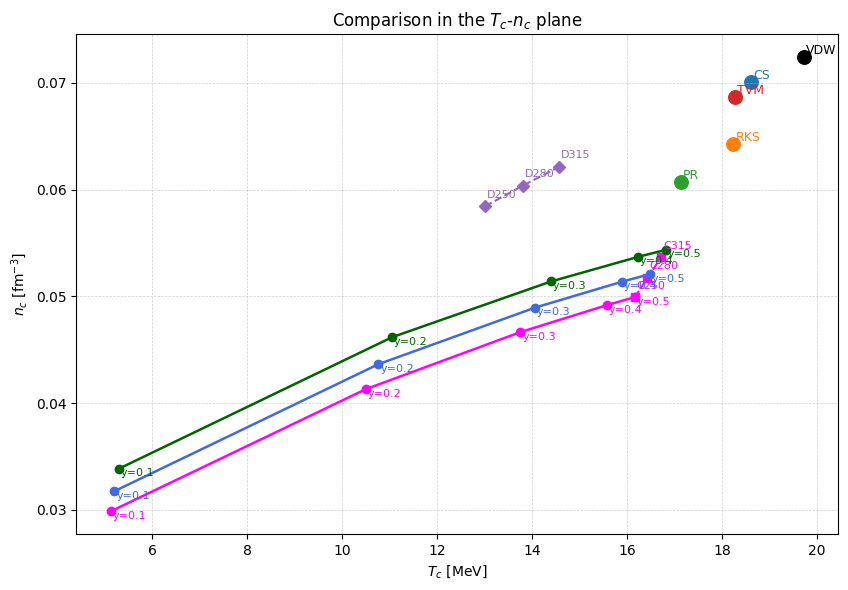

PosixPath('/Users/dajuarez4/Documents/QuarkMatt/nuclear_matter_workflows/results/tc_nc_comparison_combined_vs_clausius_fixed_y')

In [9]:
fig, ax = plt.subplots(figsize=(8.6, 6.0))

for row in base_df.itertuples(index=False):
    color = COLOR_MAP.get(row.model, 'black')
    ax.scatter(row.Tc, row.nc, color=color, s=95, marker='o')
    ax.text(row.Tc + 0.04, row.nc + 0.0003, row.label, color=color, fontsize=9)

scan_style = {
    'clausius': {'color': 'magenta', 'marker': 's', 'linestyle': '--'},
    'dieterici': {'color': 'tab:purple', 'marker': 'D', 'linestyle': '--'},
}
for scan_model, group in scan_reference_df.groupby('scan_model'):
    group = group.sort_values('target_k0')
    style = scan_style[scan_model]
    label = 'Combined Clausius scan' if scan_model == 'clausius' else 'Combined Dieterici scan'
    ax.plot(group['Tc'], group['nc'], color=style['color'], marker=style['marker'], ls=style['linestyle'], lw=1.5, label=label)
    for _, row in group.iterrows():
        ax.text(row['Tc'] + 0.04, row['nc'] + 0.0008, f"{scan_model[0].upper()}{int(row['target_k0'])}", color=style['color'], fontsize=8)

for target_k0, group in fixed_y_df.groupby('target_k0'):
    group = group.sort_values('y', ascending=False)
    color = COLOR_MAP.get(float(target_k0), None)
    label = rf"Clausius fixed-$y$, $K_0={int(round(float(target_k0)))}$ MeV"
    ax.plot(group['Tc'], group['nc'], color=color, marker='o', lw=1.8, label=label)
    for _, row in group.iterrows():
        ax.text(row['Tc'] + 0.04, row['nc'] - 0.0007, f"y={row['y']:.1f}", color=color, fontsize=8)

ax.set_xlabel(r'$T_c$ [MeV]')
ax.set_ylabel(r'$n_c$ [fm$^{-3}$]')
ax.set_title(r'Comparison in the $T_c$-$n_c$ plane')
ax.grid(True, ls='--', lw=0.5, alpha=0.6)
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
fig.savefig(output_dir / 'tc_nc_combined_vs_clausius_fixed_y_overlay.png', dpi=300)
plt.show()

output_dir


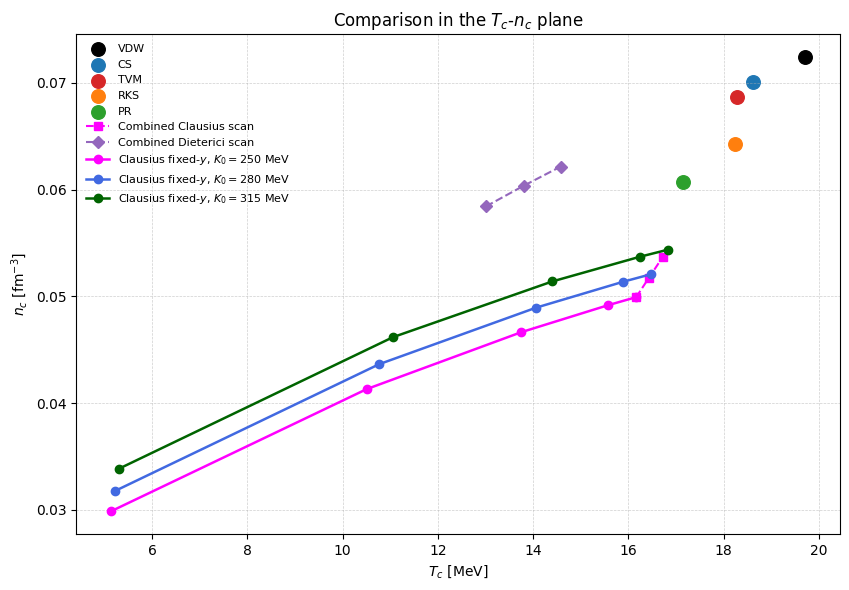

In [10]:
fig, ax = plt.subplots(figsize=(8.6, 6.0))

for row in base_df.itertuples(index=False):
    color = COLOR_MAP.get(row.model, "black")
    ax.scatter(row.Tc, row.nc, color=color, s=95, marker="o", label=row.label)

scan_style = {
    "clausius": {"color": "magenta", "marker": "s", "linestyle": "--"},
    "dieterici": {"color": "tab:purple", "marker": "D", "linestyle": "--"},
}

scan_label_map = {
    "clausius": "Combined Clausius scan",
    "dieterici": "Combined Dieterici scan",
}

for scan_model, group in scan_reference_df.groupby("scan_model"):
    group = group.sort_values("target_k0")
    style = scan_style[scan_model]
    ax.plot(
        group["Tc"],
        group["nc"],
        color=style["color"],
        marker=style["marker"],
        ls=style["linestyle"],
        lw=1.5,
        label=scan_label_map[scan_model],
    )

for target_k0, group in fixed_y_df.groupby("target_k0"):
    group = group.sort_values("y", ascending=False)
    color = COLOR_MAP.get(float(target_k0), None)
    ax.plot(
        group["Tc"],
        group["nc"],
        color=color,
        marker="o",
        lw=1.8,
        label=rf"Clausius fixed-$y$, $K_0={int(round(float(target_k0)))}$ MeV",
    )

handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), frameon=False, fontsize=8)

ax.set_xlabel(r"$T_c$ [MeV]")
ax.set_ylabel(r"$n_c$ [fm$^{-3}$]")
ax.set_title(r"Comparison in the $T_c$-$n_c$ plane")
ax.grid(True, ls="--", lw=0.5, alpha=0.6)

plt.tight_layout()
fig.savefig(output_dir / "tc_nc_combined_vs_clausius_fixed_y_overlay_clean.png", dpi=300)
plt.show()

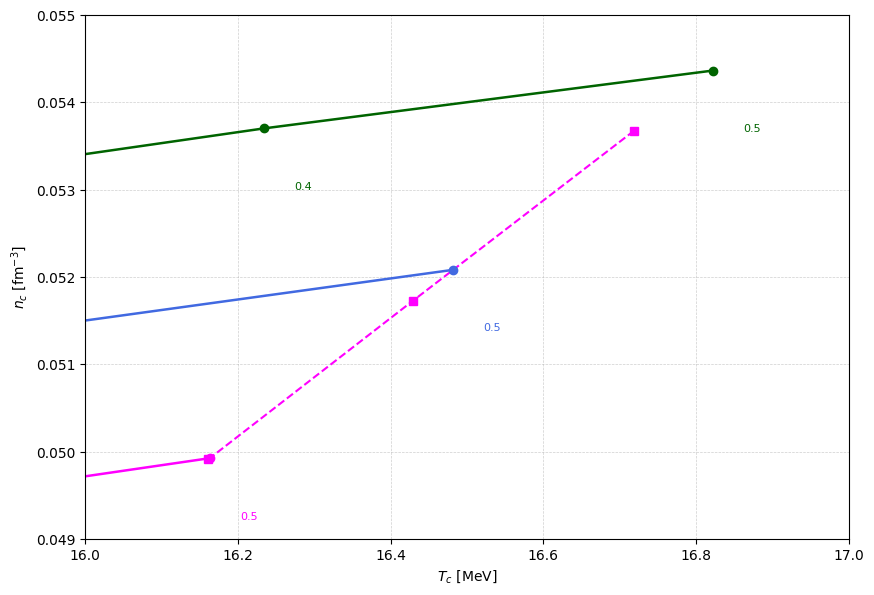

In [31]:
fig, ax = plt.subplots(figsize=(8.6, 6.0))

for row in base_df.itertuples(index=False):
    color = COLOR_MAP.get(row.model, "black")
    ax.scatter(row.Tc, row.nc, color=color, s=95, marker="o", label=row.label)

scan_style = {
    "clausius": {"color": "magenta", "marker": "s", "linestyle": "--"},
    "dieterici": {"color": "tab:purple", "marker": "D", "linestyle": "--"},
}

scan_label_map = {
    "clausius": "clausius: First three values (small $K_0$)",
    "dieterici": "dieterici: First three values (small $K_0$)",
}

for scan_model, group in scan_reference_df.groupby("scan_model"):
    group = group.sort_values("target_k0")
    style = scan_style[scan_model]
    ax.plot(
        group["Tc"],
        group["nc"],
        color=style["color"],
        marker=style["marker"],
        ls=style["linestyle"],
        lw=1.5,
        label=scan_label_map[scan_model],
    )

for target_k0, group in fixed_y_df.groupby("target_k0"):
    group = group.sort_values("y", ascending=False)
    color = COLOR_MAP.get(float(target_k0), None)
    ax.plot(
        group["Tc"],
        group["nc"],
        color=color,
        marker="o",
        lw=1.8,
        label=rf"Clausius fixed-$y$, $K_0={int(round(float(target_k0)))}$ MeV",
    )
    for _, row in group.iterrows():
        if row["y"] > 0.0:
            ax.text(
                row["Tc"] + 0.04,
                row["nc"] - 0.0007,
                f"{row['y']:.1f}",
                color=color,
                fontsize=8,
            )

handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
# ax.legend(unique.values(), unique.keys(), frameon=False, fontsize=8)

ax.set_xlabel(r"$T_c$ [MeV]")
ax.set_ylabel(r"$n_c$ [fm$^{-3}$]")
# ax.set_title(r"Comparison in the $T_c$-$n_c$ plane")
ax.grid(True, ls="--", lw=0.5, alpha=0.6)
# plt.xlim(16,17)
# plt.ylim(0.045,0.055)
# ax.set_xlim(16, 17)
# ax.set_ylim(0.045, 0.055)

plt.tight_layout()

ax.set_xlim(16, 17)
ax.set_ylim(0.049, 0.055)

for text in ax.texts:
    text.set_clip_on(True)

plt.show()
# plt.show()